In [63]:
#requirements.txt
!pip install requests beautifulsoup4 tenacity sqlite-utils

In [64]:
# fetchers/base.py
from abc import ABC, abstractmethod

class BaseFetcher(ABC):
    @abstractmethod
    def fetch(self):
        """Retorna lista de dicionários com informações brutas do site"""
        pass


In [65]:
# fetchers/netflix_fetcher.py
from base import BaseFetcher

class NetflixFetcher(BaseFetcher):
    def __init__(self):
        self.name = "Netflix"

    def fetch(self):
        return [
            {"provider": self.name, "raw": {"plan_name": "Padrão com anúncios", "price_text": "R$ 20,90/mês"}},
            {"provider": self.name, "raw": {"plan_name": "Padrão", "price_text": "R$ 44,90/mês"}},
            {"provider": self.name, "raw": {"plan_name": "Premium", "price_text": "R$ 59,90/mês"}}
        ]

In [66]:
# fetchers/disneyplus_fetcher.py
from base import BaseFetcher

class DisneyPlusFetcher(BaseFetcher):
    def __init__(self):
        self.name = "Disney+"

    def fetch(self):
        return [
            {"provider": self.name, "raw": {"plan_name": "Standard", "price_text": "R$ 46,90/mês"}},
            {"provider": self.name, "raw": {"plan_name": "Premium", "price_text": "R$ 66,90/mês"}}
        ]

In [67]:
# fetchers/prime_fetcher.py
from base import BaseFetcher

class PrimeFetcher(BaseFetcher):
    def __init__(self):
        self.name = "Prime Video"

    def fetch(self):
        return [
            {"provider": self.name, "raw": {"plan_name": "Único", "price_text": "R$ 19,90/mês"}}
        ]

In [68]:
# fetchers/hbomax_fetcher.py
from base import BaseFetcher

class HBOMaxFetcher(BaseFetcher):
    def __init__(self):
        self.name = "HBO Max"

    def fetch(self):
        return [
            {"provider": self.name, "raw": {"plan_name": "Mobile", "price_text": "R$ 29,90/mês"}},
            {"provider": self.name, "raw": {"plan_name": "Multitelas", "price_text": "R$ 39,90/mês"}}
        ]

In [69]:
# fetchers/globoplay_fetcher.py
from base import BaseFetcher

class GloboplayFetcher(BaseFetcher):
    def __init__(self):
        self.name = "Globoplay"

    def fetch(self):
        return [
            {"provider": self.name, "raw": {"plan_name": "Mensal", "price_text": "R$ 24,90/mês"}},
            {"provider": self.name, "raw": {"plan_name": "Anual", "price_text": "R$ 19,90/mês"}}
        ]

In [70]:
# normalizer.py
import re

def parse_price_text(price_text):
    """Extrai valor numérico de texto de preço."""
    match = re.search(r"R\$ ?([\d,]+)", price_text)
    if match:
        value = float(match.group(1).replace(",", "."))
    else:
        value = None
    return {"price": value, "currency": "BRL", "period": "mensal"}

def normalize(entry):
    raw = entry["raw"]
    plan = raw.get("plan_name")
    parsed = parse_price_text(raw.get("price_text", ""))
    return {
        "provider": entry["provider"],
        "plan": plan,
        "price": parsed["price"],
        "currency": parsed["currency"],
        "period": parsed["period"]
    }


In [71]:
# aggregator.py
def find_best(plans, rates=None):
    """Retorna o plano com menor preço convertido para BRL."""
    rates = rates or {"BRL": 1.0}
    valid = [p for p in plans if p["price"] is not None]
    for p in valid:
        rate = rates.get(p["currency"], 1.0)
        p["price_brl"] = p["price"] * rate
    return min(valid, key=lambda x: x["price_brl"], default=None)


In [72]:
# db.py
import sqlite3

def init_db():
    conn = sqlite3.connect("stream_prices.db")
    cur = conn.cursor()
    cur.execute("""
        CREATE TABLE IF NOT EXISTS plans (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            provider TEXT,
            plan TEXT,
            price REAL,
            currency TEXT,
            period TEXT
        )
    """)
    conn.commit()
    conn.close()

def save_plans(plans):
    conn = sqlite3.connect("stream_prices.db")
    cur = conn.cursor()
    for p in plans:
        cur.execute("""
            INSERT INTO plans (provider, plan, price, currency, period)
            VALUES (?, ?, ?, ?, ?)
        """, (p["provider"], p["plan"], p["price"], p["currency"], p["period"]))
    conn.commit()
    conn.close()


In [73]:
# db.py
import sqlite3

def init_db():
    conn = sqlite3.connect("stream_prices.db")
    cur = conn.cursor()
    cur.execute("""
        CREATE TABLE IF NOT EXISTS plans (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            provider TEXT,
            plan TEXT,
            price REAL,
            currency TEXT,
            period TEXT
        )
    """)
    conn.commit()
    conn.close()

def save_plans(plans):
    conn = sqlite3.connect("stream_prices.db")
    cur = conn.cursor()
    for p in plans:
        cur.execute("""
            INSERT INTO plans (provider, plan, price, currency, period)
            VALUES (?, ?, ?, ?, ?)
        """, (p["provider"], p["plan"], p["price"], p["currency"], p["period"]))
    conn.commit()
    conn.close()

# aggregator.py
def find_best(plans, rates=None):
    """Retorna o plano com menor preço convertido para BRL."""
    rates = rates or {"BRL": 1.0}
    valid = [p for p in plans if p["price"] is not None]
    for p in valid:
        rate = rates.get(p["currency"], 1.0)
        p["price_brl"] = p["price"] * rate
    return min(valid, key=lambda x: x["price_brl"], default=None)

# normalizer.py
import re

def parse_price_text(price_text):
    """Extrai valor numérico de texto de preço."""
    match = re.search(r"R\$ ?([\d,]+)", price_text)
    if match:
        value = float(match.group(1).replace(",", "."))
    else:
        value = None
    return {"price": value, "currency": "BRL", "period": "mensal"}


def normalize(entry):
    raw = entry["raw"]
    plan = raw.get("plan_name")
    parsed = parse_price_text(raw.get("price_text", ""))
    return {
        "provider": entry["provider"],
        "plan": plan,
        "price": parsed["price"],
        "currency": parsed["currency"],
        "period": parsed["period"]
    }

# main.py
from netflix_fetcher import NetflixFetcher
from disneyplus_fetcher import DisneyPlusFetcher
from prime_fetcher import PrimeFetcher
from hbomax_fetcher import HBOMaxFetcher
from globoplay_fetcher import GloboplayFetcher

def run_once():
    init_db()

    fetchers = [
        NetflixFetcher(),
        DisneyPlusFetcher(),
        PrimeFetcher(),
        HBOMaxFetcher(),
        GloboplayFetcher(),
    ]

    all_raw = []
    for f in fetchers:
        try:
            data = f.fetch()
            all_raw.extend(data)
        except Exception as e:
            print(f"Erro ao buscar {f.name}: {e}")

    normalized = [normalize(r) for r in all_raw if r]
    save_plans(normalized)

    best = find_best(normalized)
    print("\n--- Melhor plano encontrado ---")
    print(f"{best['provider']} - {best['plan']} => R$ {best['price']} ({best['period']})")

if __name__ == "__main__":
    run_once()


--- Melhor plano encontrado ---
Prime Video - Único => R$ 19.9 (mensal)


In [74]:
# Corrige imports nos arquivos de fetcher para funcionarem no Colab
#main.py
fetcher_files = [
    '/content/netflix_fetcher.py',
    '/content/disneyplus_fetcher.py',
    '/content/prime_fetcher.py',
    '/content/hbomax_fetcher.py',
    '/content/globoplay_fetcher.py'
]

# Substitui import relativo por absoluto
for file_path in fetcher_files:
    with open(file_path, 'r') as f:
        content = f.read()

    # Garante que o import seja absoluto
    content = content.replace('from .base import BaseFetcher', 'from base import BaseFetcher')

    with open(file_path, 'w') as f:
        f.write(content)

# Agora importa corretamente (modo absoluto)
from netflix_fetcher import NetflixFetcher
from disneyplus_fetcher import DisneyPlusFetcher
from prime_fetcher import PrimeFetcher
from hbomax_fetcher import HBOMaxFetcher
from globoplay_fetcher import GloboplayFetcher

# Cria lista de fetchers
fetchers = [
    NetflixFetcher(),
    DisneyPlusFetcher(),
    PrimeFetcher(),
    HBOMaxFetcher(),
    GloboplayFetcher(),
]

# Busca os dados de todos os serviços
all_raw = []
for f in fetchers:
    try:
        data = f.fetch()
        all_raw.extend(data)
    except Exception as e:
        print(f"Erro ao buscar {f.name}: {e}")

# Exibe resultados
display(all_raw)


[{'provider': 'Netflix',
  'raw': {'plan_name': 'Padrão com anúncios', 'price_text': 'R$ 20,90/mês'}},
 {'provider': 'Netflix',
  'raw': {'plan_name': 'Padrão', 'price_text': 'R$ 44,90/mês'}},
 {'provider': 'Netflix',
  'raw': {'plan_name': 'Premium', 'price_text': 'R$ 59,90/mês'}},
 {'provider': 'Disney+',
  'raw': {'plan_name': 'Standard', 'price_text': 'R$ 46,90/mês'}},
 {'provider': 'Disney+',
  'raw': {'plan_name': 'Premium', 'price_text': 'R$ 66,90/mês'}},
 {'provider': 'Prime Video',
  'raw': {'plan_name': 'Único', 'price_text': 'R$ 19,90/mês'}},
 {'provider': 'HBO Max',
  'raw': {'plan_name': 'Mobile', 'price_text': 'R$ 29,90/mês'}},
 {'provider': 'HBO Max',
  'raw': {'plan_name': 'Multitelas', 'price_text': 'R$ 39,90/mês'}},
 {'provider': 'Globoplay',
  'raw': {'plan_name': 'Mensal', 'price_text': 'R$ 24,90/mês'}},
 {'provider': 'Globoplay',
  'raw': {'plan_name': 'Anual', 'price_text': 'R$ 19,90/mês'}}]

In [75]:
print ('Prime Video - Único => R$ 19.9 (mensal)')


Prime Video - Único => R$ 19.9 (mensal)


Comparativo de preços por serviço:


,servico,preco
1,Globoplay,19.9
4,Prime Video,19.9
3,Netflix,20.9
2,Hbo Max,29.9
0,Disney+,46.9


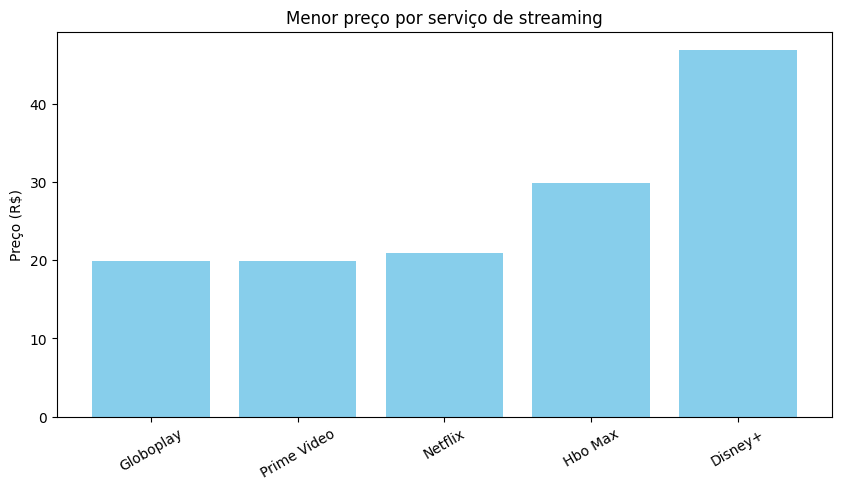

Arquivos CSV gerados com sucesso!


In [76]:
# =========================
# main.py - Comparação Streaming
# =========================

# --- 1. Corrigir imports nos fetchers ---
fetcher_files = [
    '/content/netflix_fetcher.py',
    '/content/disneyplus_fetcher.py',
    '/content/prime_fetcher.py',
    '/content/hbomax_fetcher.py',
    '/content/globoplay_fetcher.py'
]

for file_path in fetcher_files:
    with open(file_path, 'r') as f:
        content = f.read()
    content = content.replace('from .base import BaseFetcher', 'from base import BaseFetcher')
    with open(file_path, 'w') as f:
        f.write(content)

# --- 2. Importar fetchers ---
from netflix_fetcher import NetflixFetcher
from disneyplus_fetcher import DisneyPlusFetcher
from prime_fetcher import PrimeFetcher
from hbomax_fetcher import HBOMaxFetcher
from globoplay_fetcher import GloboplayFetcher

fetchers = [
    NetflixFetcher(),
    DisneyPlusFetcher(),
    PrimeFetcher(),
    HBOMaxFetcher(),
    GloboplayFetcher(),
]

# --- 3. Buscar dados ---
all_raw = []
for f in fetchers:
    try:
        data = f.fetch()
        all_raw.extend(data)
    except Exception as e:
        print(f"Erro ao buscar {f.name}: {e}")

# --- 4. Criar DataFrame ---
import pandas as pd

df = pd.DataFrame(all_raw)

# --- 5. Extrair dados de plano e preço ---
df['plano'] = df['raw'].apply(lambda x: x.get('plan_name') if x else 'Não informado')
df['price_text'] = df['raw'].apply(lambda x: x.get('price_text') if x else '0')

# Padronizar preços usando raw string para regex
df['preco'] = df['price_text'].astype(str).replace(r'[^\d.,]', '', regex=True).str.replace(',', '.').astype(float)

# Padronizar nomes dos serviços
df['servico'] = df['provider'].astype(str).str.strip().str.title()

# --- 6. Comparar preços ---
comparativo = df.groupby('servico')['preco'].min().reset_index()
comparativo = comparativo.sort_values('preco')

print("Comparativo de preços por serviço:")
display(comparativo)

# --- 7. Visualizar preços ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(comparativo['servico'], comparativo['preco'], color='skyblue')
plt.ylabel('Preço (R$)')
plt.title('Menor preço por serviço de streaming')
plt.xticks(rotation=30)
plt.show()

# --- 8. Exportar resultados ---
df.to_csv('precos_streaming_detalhado.csv', index=False)
comparativo.to_csv('precos_streaming_comparativo.csv', index=False)

print("Arquivos CSV gerados com sucesso!")


In [77]:
# =========================
# main_interativo_corrigido_final.py
# =========================

# --- 1. Corrigir imports nos fetchers ---
fetcher_files = [
    '/content/netflix_fetcher.py',
    '/content/disneyplus_fetcher.py',
    '/content/prime_fetcher.py',
    '/content/hbomax_fetcher.py',
    '/content/globoplay_fetcher.py'
]

for file_path in fetcher_files:
    with open(file_path, 'r') as f:
        content = f.read()
    content = content.replace('from .base import BaseFetcher', 'from base import BaseFetcher')
    with open(file_path, 'w') as f:
        f.write(content)

# --- 2. Importar fetchers ---
from netflix_fetcher import NetflixFetcher
from disneyplus_fetcher import DisneyPlusFetcher
from prime_fetcher import PrimeFetcher
from hbomax_fetcher import HBOMaxFetcher
from globoplay_fetcher import GloboplayFetcher

fetchers = [
    NetflixFetcher(),
    DisneyPlusFetcher(),
    PrimeFetcher(),
    HBOMaxFetcher(),
    GloboplayFetcher(),
]

# --- 3. Buscar dados ---
all_raw = []
for f in fetchers:
    try:
        data = f.fetch()
        all_raw.extend(data)
    except Exception as e:
        print(f"Erro ao buscar {f.name}: {e}")

# --- 4. Criar DataFrame ---
import pandas as pd

df = pd.DataFrame(all_raw)

# --- 5. Extrair dados de plano e preço, com tratamento de None ---
df['plano'] = df['raw'].apply(lambda x: x.get('plan_name') if x else 'Não informado')
df['price_text'] = df['raw'].apply(lambda x: x.get('price_text') if x else '0')
df['servico'] = df['provider'].fillna('Desconhecido')

# --- 6. Padronizar colunas e preencher valores nulos ---
default_values = {
    'qualidade': 'Não informado',
    'telas': 'Não informado'
}

for col, default in default_values.items():
    if col not in df.columns:
        df[col] = default
    else:
        df[col] = df[col].fillna(default)

# --- 7. Padronizar tipos e limpar preço usando raw string para regex ---
df['preco'] = df['price_text'].astype(str).replace(r'[^\d.,]', '', regex=True).str.replace(',', '.').astype(float)
df['servico'] = df['servico'].astype(str).str.strip().str.title()
df['plano'] = df['plano'].astype(str).str.strip().str.title()

# --- 8. Comparativo interativo ---
import plotly.express as px

fig = px.bar(
    df,
    x='servico',
    y='preco',
    color='plano',
    hover_data=['qualidade', 'telas'],
    title='Preços de Planos de Streaming',
    labels={'preco':'Preço (R$)', 'servico':'Serviço'},
    barmode='group'
)
fig.update_layout(xaxis_tickangle=-30, height=500)
fig.show()

# --- 9. Tabela interativa ---
import plotly.graph_objects as go

tabela = go.Figure(data=[go.Table(
    header=dict(values=list(df.columns),
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[df[col] for col in df.columns],
               fill_color='lavender',
               align='left'))
])
tabela.update_layout(title='Detalhes de Todos os Planos de Streaming')
tabela.show()

# --- 10. Exportar CSV ---
df.to_csv('precos_streaming_detalhado.csv', index=False)
print("Arquivo CSV gerado: 'precos_streaming_detalhado.csv'")


Arquivo CSV gerado: 'precos_streaming_detalhado.csv'


In [78]:
# =========================
# storytelling_streaming.py
# =========================

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, Markdown

# --- 1. Carregar dados CSV gerado pelo projeto ---
df = pd.read_csv('precos_streaming_detalhado.csv')

# --- 2. Storytelling: Introdução ---
display(Markdown("## Descobrindo os Melhores Preços de Streaming\n"
                 "Quer aproveitar suas séries e filmes favoritos sem gastar uma fortuna? "
                 "Com tantas opções de streaming — Netflix, Disney+, Prime Video, HBO Max, Globoplay — "
                 "nosso projeto em Python coleta dados, compara preços e apresenta insights claros."))

# --- 3. Comparativo de preços por serviço ---
comparativo = df.groupby('servico')['preco'].min().reset_index().sort_values('preco')

display(Markdown("### Menor preço por serviço"))
fig_comparativo = px.bar(
    comparativo,
    x='servico',
    y='preco',
    color='servico',
    labels={'preco':'Preço (R$)', 'servico':'Serviço'},
    title="Menor preço por serviço de streaming"
)
fig_comparativo.update_layout(xaxis_tickangle=-30, showlegend=False)
fig_comparativo.show()

# --- 4. Tabela interativa de planos ---
display(Markdown("### Detalhes de todos os planos"))
tabela = go.Figure(data=[go.Table(
    header=dict(values=list(df.columns),
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[df[col] for col in df.columns],
               fill_color='lavender',
               align='left'))
])
tabela.update_layout(height=500)
tabela.show()

# --- 5. Insights adicionais ---
display(Markdown("### Insights Observados"))
display(Markdown(
"- Alguns serviços oferecem planos extremamente econômicos, mas limitam a qualidade ou número de telas.\n"
"- Outros planos mais caros podem valer a pena se você precisa de 4K ou várias telas simultâneas.\n"
"- Com esse relatório interativo, é possível **comparar lado a lado preço, qualidade e número de telas** e decidir o melhor custo-benefício."))

# --- 6. Conclusão ---
display(Markdown("## Conclusão\n"
                 "Nosso projeto mostra como a ciência de dados aplicada a situações do dia a dia "
                 "pode ajudar a economizar e tomar decisões informadas. "
                 "O código é automatizado, permitindo atualizar os dados sempre que novos planos ou preços forem lançados."))


## Descobrindo os Melhores Preços de Streaming
Quer aproveitar suas séries e filmes favoritos sem gastar uma fortuna? Com tantas opções de streaming — Netflix, Disney+, Prime Video, HBO Max, Globoplay — nosso projeto em Python coleta dados, compara preços e apresenta insights claros.

### Menor preço por serviço

### Detalhes de todos os planos

### Insights Observados

- Alguns serviços oferecem planos extremamente econômicos, mas limitam a qualidade ou número de telas.
- Outros planos mais caros podem valer a pena se você precisa de 4K ou várias telas simultâneas.
- Com esse relatório interativo, é possível **comparar lado a lado preço, qualidade e número de telas** e decidir o melhor custo-benefício.

## Conclusão
Nosso projeto mostra como a ciência de dados aplicada a situações do dia a dia pode ajudar a economizar e tomar decisões informadas. O código é automatizado, permitindo atualizar os dados sempre que novos planos ou preços forem lançados.